# 02 — Pairwise-overlap DTW clustering

**Notebook 2 of 9 — Drosophila book-chapter production pipeline**

**Purpose:** Cluster retained normalized delta-area trajectories from pairwise-overlap DTW dissimilarity profiles at k = 2 and k = 3.

**Primary inputs:** `data/processed/df_wide_delta.csv`

**Primary outputs:** `data/processed/k2_cluster_assignments_dtw.csv`; `data/processed/k3_cluster_assignments_dtw.csv`; `figures/Book_Chapter_Fig_2.png`; `figures/Book_Chapter_Fig_2.tiff`

**Manuscript role:** DTW clustering methods and results; produces Book Chapter Figure 2 and assignments used in the complete six-stream audits and consensus analyses.

**Project authors:** Tim Rogalsky, Nicolas Malagon, Lia Campbell-Enns, Matthaeus Dyck

**Reproducibility:** Designed for fresh-kernel execution in production order 01→09 using repository-relative paths. It consumes the explicit normalized trajectory interface written by Notebook 01 and requires no private, diagnostic, or obsolete provenance artifact.

In [1]:
# Repository convention: data/raw/ contains source datasets, data/processed/ contains
# derived datasets and analysis outputs, and figures/ contains generated figures.
from pathlib import Path

PROJECT_ROOT = Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def pairwise_overlap_dtw_distance_matrix(series):
    """Compute pairwise DTW over each pair's shared valid time interval."""
    series = np.asarray(series)
    if series.ndim != 2:
        raise ValueError("series must be a 2D numpy array of time series.")

    n_series = series.shape[0]
    first_valid = np.empty(n_series, dtype=int)
    last_valid = np.empty(n_series, dtype=int)

    for i, values in enumerate(series):
        finite_indices = np.flatnonzero(np.isfinite(values))
        if finite_indices.size == 0:
            raise ValueError(f"Series {i} contains no finite observations.")
        first_valid[i] = finite_indices[0]
        last_valid[i] = finite_indices[-1]
        if not np.isfinite(values[first_valid[i]:last_valid[i] + 1]).all():
            raise ValueError(
                f"Series {i} contains an internal non-finite value between its first "
                "and last finite observations."
            )

    distance_matrix = np.zeros((n_series, n_series), dtype=float)
    for i in range(n_series):
        for j in range(i + 1, n_series):
            start = max(first_valid[i], first_valid[j])
            end = min(last_valid[i], last_valid[j])
            if start > end:
                raise ValueError(
                    f"Series {i} and {j} have no shared developmental-time interval."
                )

            x_i = series[i, start:end + 1]
            x_j = series[j, start:end + 1]
            if not np.isfinite(x_i).all() or not np.isfinite(x_j).all():
                raise ValueError(
                    f"Series {i} and {j} contain a non-finite value within their shared interval."
                )

            distance = dtw(x_i, x_j)
            if not np.isfinite(distance):
                raise ValueError(f"DTW produced a non-finite distance for series {i} and {j}.")
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    if not np.isfinite(distance_matrix).all():
        raise ValueError("The completed DTW distance matrix contains non-finite values.")

    return distance_matrix

## Method context and DTW revalidation

DTW aligns trajectories nonlinearly. The earlier implementation removed missing observations before comparison, which could collapse unavailable endpoints and misalign developmental-time positions. The production method preserves the padded time coordinate, excludes cells with more than 25% missingness, and computes pairwise-overlap DTW only over the shared valid interval for each pair. Retained trajectories contain endpoint missingness only; no value is imputed.

Reference: Berndt, D. J., and Clifford, J. (1994), *Using Dynamic Time Warping to Find Patterns in Time Series*.

#### Notes
- This delta-only notebook requires `data/processed/df_wide_delta.csv`, produced by **01_Preprocessing.ipynb** from `data/raw/Delta cell area.xlsx`.
- Generated datasets are written to `data/processed/`; generated figures are written to `figures/`.


## Production data and clustering scope

The input contains 131 normalized delta-area trajectories from three movies with 39, 41, and 48 observations. Applying the accepted 25% missingness threshold retains 108 trajectories in deterministic source-column order. The notebook derives computational partitions at k = 2 and k = 3; cluster labels are method-local identifiers rather than biological cell types.

#### Production steps
1. Load and validate the normalized delta-area trajectories.
2. Apply the missingness threshold without truncation or imputation.
3. Compute the 108 × 108 pairwise-overlap DTW matrix.
4. Treat each matrix row as a DTW dissimilarity profile and cluster the unscaled profiles with Ward and ordinary KMeans at k = 2 and k = 3.
5. Export DW and DK assignments and produce Book Chapter Figure 2.

In [3]:
# Set the environment variable to avoid memory leak in KMeans
import os

# Set the environment variable 
os.environ['OMP_NUM_THREADS'] = '1'


In [4]:
# Dependencies are managed by the repository requirements.txt; do not install packages from this notebook.


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import time
import warnings
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import ClusterWarning, linkage, dendrogram
from tslearn.metrics import dtw
from scipy.cluster.hierarchy import fcluster
from tslearn.barycenters import dtw_barycenter_averaging
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, rand_score


c:\venvs\drosophila-book\Lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


### 1. Load the delta data from CSV

Read the normalized, non-imputed wide-format delta-area trajectories produced by Notebook 01.

#### Production input

`data/processed/df_wide_delta.csv` contains normalized delta values in wide format. Rows are developmental time points and columns are deterministic cell identifiers. Missing observations remain as NaN values and occur only at trajectory endpoints among retained cells.


#### Delta trajectory structure

Cell identifiers retain their movie prefix, and the source column order defines the production row order for the DTW dissimilarity-profile matrix and all assignment exports. Developmental observations are spaced at 20-minute intervals.


In [6]:
# Load the sole delta-derived production input used by this notebook.
df_wide_delta = pd.read_csv(PROCESSED_DATA_DIR / 'df_wide_delta.csv')

print("df_wide_delta:")
df_wide_delta.info()
display(df_wide_delta.head())


df_wide_delta:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Columns: 131 entries, Mov. 1 - Cell 1 to Mov. 3 - Cell 9
dtypes: float64(131)
memory usage: 49.3 KB


,Mov. 1 - Cell 1,Mov. 1 - Cell 10,Mov. 1 - Cell 10.1,Mov. 1 - Cell 11,Mov. 1 - Cell 11.1,Mov. 1 - Cell 12,Mov. 1 - Cell 12.1,Mov. 1 - Cell 13,Mov. 1 - Cell 13.1,Mov. 1 - Cell 14,...,Mov. 3 - Cell 53,Mov. 3 - Cell 54,Mov. 3 - Cell 55,Mov. 3 - Cell 56,Mov. 3 - Cell 57,Mov. 3 - Cell 58,Mov. 3 - Cell 6,Mov. 3 - Cell 7,Mov. 3 - Cell 8,Mov. 3 - Cell 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.593469,0.568741,0.591821,0.651166,0.558849,NaN,0.552255,0.642922,0.687435,0.547310
1,NaN,0.591864,0.603343,0.674849,0.603070,0.666380,0.602798,NaN,0.602526,NaN,...,0.603360,0.707216,0.466532,0.677544,0.634682,NaN,0.567093,0.539068,0.372565,0.565444
2,NaN,0.544448,0.650595,0.547833,0.656210,0.497030,0.661824,NaN,0.667438,NaN,...,0.471477,0.621494,0.585227,0.507746,0.539066,NaN,0.580280,0.662707,0.712163,0.608305
3,NaN,0.651136,0.527207,0.547833,0.521593,0.629121,0.515979,NaN,0.510365,NaN,...,0.626441,0.583577,0.603358,0.844042,0.603360,NaN,0.591819,0.555552,0.647869,0.623141
4,NaN,0.581705,0.642916,0.563076,0.648779,0.576625,0.654643,NaN,0.660506,NaN,...,0.519285,0.590171,0.639627,0.529177,0.389051,NaN,0.726999,0.535769,0.494557,0.535771


### 2. Prepare the data

- Calculate the number of time steps per movie.
- Set a boolean flag (`truncate_series`) to truncate all time series to the shortest length.
- Set a threshold (`nan_threshold`, a relative frequency) to filter out time series with excessive NaN values.
- Clean the delta DataFrame and convert it to the `delta_series` NumPy array.
- Create `delta_identifier_map` to track the deterministic cell order.

In [7]:
# Derive movie lengths from the delta columns only. This is descriptive because
# the locked production setting below does not truncate trajectories.
movie_names = list(dict.fromkeys(column.split(' - Cell', 1)[0] for column in df_wide_delta.columns))
movie_time_steps = {}
for movie in movie_names:
    movie_columns = [column for column in df_wide_delta.columns if column.startswith(f'{movie} - Cell')]
    last_valid_indices = [
        df_wide_delta[column].last_valid_index()
        for column in movie_columns
        if df_wide_delta[column].last_valid_index() is not None
    ]
    if last_valid_indices:
        movie_time_steps[movie] = max(last_valid_indices) + 1

# Determine the minimum number of time steps across all movies
min_time_steps = min(movie_time_steps.values())

# Print the lengths of each movie and the minimum time steps
print(f"Number of time steps for each movie: {movie_time_steps}")
print(f"The minimum number of time steps across all movies is: {min_time_steps}")


Number of time steps for each movie: {'Mov. 1': 39, 'Mov. 2': 41, 'Mov. 3': 48}
The minimum number of time steps across all movies is: 39


In [8]:
# Boolean flag to truncate all time series to the shortest length
truncate_series = False

# Set a threshold for the maximum percentage of NaNs allowed
nan_threshold = 0.25

# Make a copy of the delta DataFrame to avoid changing the original.
df_wide_delta_copy = df_wide_delta.copy()

# Preserve missing values explicitly as np.nan.
df_wide_delta_copy = df_wide_delta_copy.apply(lambda x: np.where(pd.isna(x), np.nan, x))

# Truncate all series to the shortest length if truncate_series is True
if truncate_series:
    df_wide_delta_copy = df_wide_delta_copy.iloc[:min_time_steps, :]
    print(f"Note: All series have been truncated to {min_time_steps} time steps")

# Identify and filter out time series with more than the allowed percentage of NaNs
valid_delta_indices = (df_wide_delta_copy.isna().mean(axis=0) <= nan_threshold)

print(f"Columns with NaNs above threshold in delta_series: {(~valid_delta_indices).sum()}")

df_wide_delta_copy = df_wide_delta_copy.loc[:, valid_delta_indices]

# Re-create the identifier map after filtering
delta_identifier_map = {cell: idx for idx, cell in enumerate(df_wide_delta_copy.columns)}

# Convert the retained delta trajectories to a row-wise NumPy array.
delta_series = df_wide_delta_copy.T.to_numpy()


Columns with NaNs above threshold in delta_series: 23


In [9]:
# The in-memory delta_series array is consumed directly below.
# Redundant root-level NumPy-array CSV exports are intentionally omitted.


### 3. Superseded direct-DTW exploration

The disabled `TimeSeriesKMeans(metric="dtw")` block is retained only for provenance. It does not implement the pairwise-overlap rule and is not part of production execution.

In [10]:
# Legacy exploratory code: disabled and not part of the corrected pairwise-overlap DTW pipeline.
# Direct TimeSeriesKMeans does not implement the pair-specific shared-time overlap rule used here.
# start_time = time.time()  # Start timing

# # Function to report clustering results
# def report_clustering_results(series, series_name):
#     print(f"Clustering results for {series_name}:")
#     for k in range(2, 11):
#         model = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=123)
#         cluster_labels = model.fit_predict(series)
#         num_clusters = len(set(cluster_labels))
#         print(f"Number of clusters for k={k}: {num_clusters}")

# # Clustering on delta_series
# report_clustering_results(delta_series, "delta_series")
# end_time = time.time()  # End timing
# elapsed_time = end_time - start_time  # Calculate elapsed time
# print(f"Time taken: {elapsed_time:.4f} seconds")

### Provenance boundary

Stored historical direct-DTW outputs do not describe the production pairwise-overlap DTW analysis and do not contribute assignments downstream.

### 4. Hierarchical clustering using DTW dissimilarity profiles
- Each row of the production pairwise-overlap DTW matrix is treated by SciPy as an observation vector, or DTW dissimilarity profile. Ward linkage operates on Euclidean distances between these profiles; it is not applied directly to the pairwise DTW metric.
- SciPy would normally emit a `ClusterWarning` because the symmetric, hollow square observation matrix resembles an uncondensed distance matrix. That expected warning is suppressed only around the Ward call because the rows are intentionally supplied as DTW dissimilarity-profile observations.
- Strengths: Does not require specifying the number of clusters in advance. Captures nested clusters.
- Best For: Nested or hierarchical structures in data.
- https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering 

Retained cells / unique Cell_Name values: 108 / 108
DTW matrix shape: (108, 108); finite=True; symmetric=True; zero diagonal=True
K2_DW label-specific sizes: {1: 34, 2: 74}
K2_DK label-specific sizes: {1: 40, 2: 68}
K3_DW label-specific sizes: {'1': 34, '2a': 25, '2b': 49}
DW vs DK: RI=0.8940809968847352; NMI=0.7274904500196255; ARI=0.786549875629038
DW2 -> DK1 cells: ['Mov. 2 - Cell C4', 'Mov. 3 - Cell 4', 'Mov. 3 - Cell 43', 'Mov. 3 - Cell 50', 'Mov. 3 - Cell 54', 'Mov. 3 - Cell 7']
K3_DK native-label sizes: {0: 49, 1: 31, 2: 28}
K3 DW vs DK: RI=0.763239875389; ARI=0.480327428465; NMI=0.618878219442
KMeans inertia for k=1..4:


,k,inertia
0,1,140.080572
1,2,59.482951
2,3,44.370525
3,4,36.550547


K3_DK seed stability: 29/30 exact up to permutation; alternative seed 10 ARI=0.977916572929


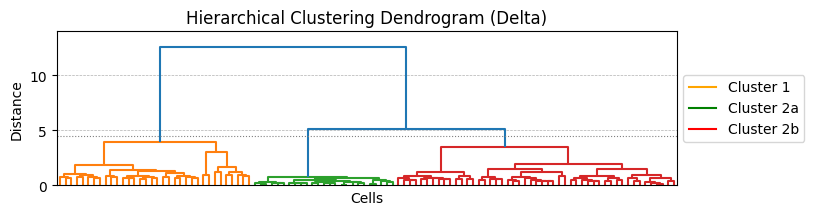

In [11]:
# Plot an already-constructed Ward hierarchy without recomputing DTW.
def plot_dendrogram(Z, color_threshold=4.5, max_distance=14):
    # Plot the dendrogram
    plt.figure(figsize=(8, 2))
    dendrogram(Z, no_labels=True, color_threshold=color_threshold)
    plt.title('Hierarchical Clustering Dendrogram (Delta)')
    plt.xlabel('Cells')
    plt.ylabel('Distance')
    plt.ylim(0, max_distance)
    plt.axhline(color_threshold, color='gray', linestyle=':', linewidth=0.8)
    plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)

    # Create color-matching legend handles
    cluster1_line = mlines.Line2D([], [], color='orange', label='Cluster 1')
    cluster2a_line = mlines.Line2D([], [], color='green', label='Cluster 2a')
    cluster2b_line = mlines.Line2D([], [], color='red', label='Cluster 2b')

    # Add legend outside plot
    plt.legend(
        handles=[cluster1_line, cluster2a_line, cluster2b_line],
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        borderaxespad=0
    )

    plt.show()

# Retained-cell identity and order are inherited deterministically from the source columns.
retained_cell_names = list(df_wide_delta_copy.columns)
expected_retained_cell_names = df_wide_delta.columns[valid_delta_indices.to_numpy()].tolist()
assert len(delta_series) == 108, "Expected exactly 108 retained cells."
assert len(retained_cell_names) == 108, "Expected exactly 108 retained Cell_Name values."
assert pd.Index(retained_cell_names).is_unique, "Retained Cell_Name values must be unique."
assert retained_cell_names == expected_retained_cell_names, "Retained-cell order is not deterministic."
assert retained_cell_names == [
    name for name, index in sorted(delta_identifier_map.items(), key=lambda item: item[1])
], "Identifier-map order differs from the retained-cell order."

# Compute the corrected pairwise-overlap DTW matrix exactly once. Every production
# clustering method below uses its raw rows as 108-dimensional dissimilarity profiles.
dtw_distance_matrix = pairwise_overlap_dtw_distance_matrix(delta_series)
matrix_tolerance = 1e-12
assert dtw_distance_matrix.shape == (108, 108), f"Unexpected DTW matrix shape: {dtw_distance_matrix.shape}"
assert np.isfinite(dtw_distance_matrix).all(), "DTW matrix contains non-finite entries."
assert np.allclose(dtw_distance_matrix, dtw_distance_matrix.T, rtol=0.0, atol=matrix_tolerance), (
    "DTW matrix is not symmetric within the required tolerance."
)
assert np.allclose(np.diag(dtw_distance_matrix), 0.0, rtol=0.0, atol=matrix_tolerance), (
    "DTW matrix diagonal is not zero within the required tolerance."
)

# The square matrix is intentionally an observation matrix of DTW dissimilarity profiles.
# Suppress only SciPy's shape-based warning; Ward still acts on the raw profile rows.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ClusterWarning)
    Z_delta = linkage(dtw_distance_matrix, method="ward")
K2_DW = fcluster(Z_delta, 2, criterion="maxclust").astype(int)
hierarchical_2_labels = K2_DW
hierarchical_3_labels = fcluster(Z_delta, 3, criterion="maxclust").astype(int)
hierarchical_label_names = {1: "1", 2: "2a", 3: "2b"}
K3_DW = np.asarray([hierarchical_label_names[label] for label in hierarchical_3_labels])

assert set(K2_DW) == {1, 2}
assert {label: int(np.sum(K2_DW == label)) for label in (1, 2)} == {1: 34, 2: 74}
assert set(K3_DW) == {"1", "2a", "2b"}
assert {label: int(np.sum(K3_DW == label)) for label in ("1", "2a", "2b")} == {
    "1": 34, "2a": 25, "2b": 49
}

# Production DTW-KMeans k=2 uses the same unscaled raw profile rows. The only label
# normalization is native scikit-learn 0/1 indexing plus one; no permutation is used.
dtw_kmeans_k2 = KMeans(
    n_clusters=2, init="k-means++", n_init=50, random_state=42
)
K2_DK_raw = dtw_kmeans_k2.fit_predict(dtw_distance_matrix)
K2_DK = K2_DK_raw + 1
assert set(K2_DK_raw) == {0, 1}
assert set(K2_DK) == {1, 2}
assert {label: int(np.sum(K2_DK == label)) for label in (1, 2)} == {1: 40, 2: 68}

assert np.all(K2_DK[K2_DW == 1] == 1), "Every DW1 cell must also be DK1."
expected_dw2_dk1_cells = {
    "Mov. 2 - Cell C4",
    "Mov. 3 - Cell 4",
    "Mov. 3 - Cell 43",
    "Mov. 3 - Cell 50",
    "Mov. 3 - Cell 54",
    "Mov. 3 - Cell 7",
}
observed_dw2_dk1_cells = {
    retained_cell_names[index]
    for index in np.flatnonzero((K2_DW == 2) & (K2_DK == 1))
}
assert observed_dw2_dk1_cells == expected_dw2_dk1_cells

dw_dk_ri = rand_score(K2_DW, K2_DK)
dw_dk_nmi = normalized_mutual_info_score(K2_DW, K2_DK)
dw_dk_ari = adjusted_rand_score(K2_DW, K2_DK)
assert np.isclose(dw_dk_ri, 0.8940809968847352, rtol=0.0, atol=1e-9)
assert np.isclose(dw_dk_nmi, 0.7274904500196255, rtol=0.0, atol=1e-9)
assert np.isclose(dw_dk_ari, 0.786549875629038, rtol=0.0, atol=1e-9)

# Secondary DTW-KMeans k=3 uses the identical unscaled dissimilarity-profile rows.
# Native labels 0/1/2 remain local to this pipeline and are not permuted toward Ward.
dtw_kmeans_k3 = KMeans(
    n_clusters=3, init="k-means++", n_init=50, random_state=42
)
K3_DK = dtw_kmeans_k3.fit_predict(dtw_distance_matrix)
k3_dk_sizes = {
    int(label): int(count) for label, count in zip(*np.unique(K3_DK, return_counts=True))
}
assert set(K3_DK) == {0, 1, 2}
assert sorted(k3_dk_sizes.values()) == [28, 31, 49]

dw_dk_k3_ri = rand_score(K3_DW, K3_DK)
dw_dk_k3_ari = adjusted_rand_score(K3_DW, K3_DK)
dw_dk_k3_nmi = normalized_mutual_info_score(K3_DW, K3_DK)
assert np.isclose(dw_dk_k3_ri, 0.763239875389, rtol=0.0, atol=1e-9)
assert np.isclose(dw_dk_k3_ari, 0.480327428465, rtol=0.0, atol=1e-9)
assert np.isclose(dw_dk_k3_nmi, 0.618878219442, rtol=0.0, atol=1e-9)

# Minimal descriptive inertia evidence: the largest reduction is from k=1 to k=2.
k3_inertia_curve = pd.DataFrame([
    {
        "k": k,
        "inertia": float(KMeans(
            n_clusters=k, init="k-means++", n_init=50, random_state=42
        ).fit(dtw_distance_matrix).inertia_),
    }
    for k in range(1, 5)
])
inertia_reductions = -np.diff(k3_inertia_curve["inertia"].to_numpy())
assert int(np.argmax(inertia_reductions)) == 0

# Bounded accepted stability protocol: 30 multi-start fits with seeds 0 through 29.
k3_seed_records = []
for seed in range(30):
    seeded_model = KMeans(
        n_clusters=3, init="k-means++", n_init=50, random_state=seed
    )
    seeded_labels = seeded_model.fit_predict(dtw_distance_matrix)
    seeded_sizes = sorted(np.unique(seeded_labels, return_counts=True)[1].tolist())
    k3_seed_records.append({
        "seed": seed,
        "reference_ARI": adjusted_rand_score(K3_DK, seeded_labels),
        "sorted_cluster_sizes": "/".join(map(str, seeded_sizes)),
        "inertia": float(seeded_model.inertia_),
    })
k3_seed_stability = pd.DataFrame(k3_seed_records)
k3_seed_stability["matches_reference_partition"] = np.isclose(
    k3_seed_stability["reference_ARI"], 1.0, rtol=0.0, atol=1e-12
)
non_exact_seed_fits = k3_seed_stability.loc[
    ~k3_seed_stability["matches_reference_partition"]
]
assert int(k3_seed_stability["matches_reference_partition"].sum()) == 29
assert non_exact_seed_fits["seed"].tolist() == [10]
assert np.isclose(
    non_exact_seed_fits["reference_ARI"].iloc[0],
    0.9779165729291993, rtol=0.0, atol=1e-12,
)

print(f"Retained cells / unique Cell_Name values: {len(retained_cell_names)} / {pd.Index(retained_cell_names).nunique()}")
print(f"DTW matrix shape: {dtw_distance_matrix.shape}; finite=True; symmetric=True; zero diagonal=True")
print("K2_DW label-specific sizes: {1: 34, 2: 74}")
print("K2_DK label-specific sizes: {1: 40, 2: 68}")
print("K3_DW label-specific sizes: {'1': 34, '2a': 25, '2b': 49}")
print(f"DW vs DK: RI={dw_dk_ri:.16f}; NMI={dw_dk_nmi:.16f}; ARI={dw_dk_ari:.15f}")
print(f"DW2 -> DK1 cells: {sorted(observed_dw2_dk1_cells)}")
print(f"K3_DK native-label sizes: {k3_dk_sizes}")
print(f"K3 DW vs DK: RI={dw_dk_k3_ri:.12f}; ARI={dw_dk_k3_ari:.12f}; NMI={dw_dk_k3_nmi:.12f}")
print("KMeans inertia for k=1..4:")
display(k3_inertia_curve)
print(
    f"K3_DK seed stability: {int(k3_seed_stability['matches_reference_partition'].sum())}/30 "
    f"exact up to permutation; alternative seed 10 ARI="
    f"{non_exact_seed_fits['reference_ARI'].iloc[0]:.12f}"
)

# Standalone dendrogram also consumes the already-constructed linkage.
plot_dendrogram(Z_delta, color_threshold=4.5, max_distance=14)


#### Production hierarchical structure

The production linkage supports two major groups, with one group dividing to give a three-cluster representation. Analytical Ward assignments are defined explicitly with `fcluster(..., criterion="maxclust")`. The dendrogram uses 4.5 only as a visualization threshold within the stable three-cluster interval between the relevant linkage merges; it is not an optimized analytical parameter.

For ordinary KMeans, the descriptive inertia reductions have their dominant elbow at k=2. The accepted k=3 KMeans partition is nevertheless seed-stable (29 of 30 fits across seeds 0 through 29 reproduce it exactly up to label permutation; the alternative has ARI approximately 0.978). Thus k=2 is the stronger coarse resolution, while k=3 is retained as a stable secondary finer-resolution comparison rather than a uniquely optimal cluster count.

In [12]:
def plot_cluster_centroids_dtw(series, cluster_labels=None, custom_labels=None, identifier_map=None, time_index=None, model_name="Hierarchical", Z=None, color_threshold=None):
    # For hierarchical plots, use explicit analytical labels and the threshold only for colors.
    if model_name == "Hierarchical" and Z is not None:
        if color_threshold is None:
            raise ValueError("color_threshold must be provided for hierarchical clustering.")
        if cluster_labels is None:
            raise ValueError("Explicit hierarchical cluster_labels must be provided.")

        # Extract the colors from the dendrogram
        dendro = dendrogram(Z, no_labels=True, color_threshold=color_threshold, no_plot=True)
        cluster_to_color = {i + 1: dendro['leaves_color_list'][dendro['leaves'].index(next(idx for idx in range(len(cluster_labels)) if cluster_labels[idx] == i + 1))]
                            for i in range(len(np.unique(cluster_labels)))}
    else:
        if cluster_labels is None:
            raise ValueError("Cluster labels must be provided for non-hierarchical models.")
        # Use a default colormap for non-hierarchical clustering
        cluster_to_color = {i: plt.get_cmap('tab10')(i % 10) for i in np.unique(cluster_labels)}

    # Assign default labels if custom_labels is not provided
    if custom_labels is None:
        custom_labels = {i: f"Cluster {i}" for i in np.unique(cluster_labels)}

    # List the cell identifiers in each cluster
    clusters = {i: [] for i in np.unique(cluster_labels)}
    for idx, cluster in enumerate(cluster_labels):
        clusters[cluster].append(identifier_map[idx])
    
    # Create a DataFrame to store the cluster information
    max_len = max(len(cells) for cells in clusters.values())
    cluster_df = pd.DataFrame(index=range(max_len))
    
    for cluster, cells in clusters.items():
        cluster_df[f'{custom_labels[cluster]}: {len(cells)} cells'] = pd.Series(cells)
    
    # Plot the cluster centroids (barycenters)
    unique_clusters = np.unique(cluster_labels)
    
    for idx, cluster_id in enumerate(unique_clusters):
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        cluster_series = series[cluster_indices]
        
        # Find the valid range for the cluster
        valid_start = 0
        valid_end = series.shape[1] - 1
        
        for ts in cluster_series:
            first_valid_index = np.where(~np.isnan(ts))[0][0]
            last_valid_index = np.where(~np.isnan(ts))[0][-1]
            valid_start = max(valid_start, first_valid_index)
            valid_end = min(valid_end, last_valid_index)
        
        # Truncate series within the valid range
        truncated_series = [ts[valid_start:valid_end + 1] for ts in cluster_series]
        time_range = time_index[valid_start:valid_end + 1]
        
        # Remove series with all NaNs in the truncated range
        valid_series = [ts for ts in truncated_series if not np.isnan(ts).all()]
        
        # Get the color for the cluster
        color = cluster_to_color[cluster_id]
        
        if len(valid_series) > 0:
            # Compute DTW barycenter
            barycenter = dtw_barycenter_averaging(valid_series)
            
            plt.figure(figsize=(8, 1))
            for s in cluster_series:
                plt.plot(time_index, s, alpha=0.3, color=color)
            plt.plot(time_range, barycenter, color='black', linewidth=2)
            
            # Title handling
            if idx == 0:
                plt.title(f"{model_name} with DTW metric, {custom_labels[cluster_id]} ({len(cluster_series)} cells)")
            else:
                plt.title(f"{custom_labels[cluster_id]} ({len(cluster_series)} cells)")
            
            # Axis handling
            plt.ylim(0.4, 0.8)
            if idx == len(unique_clusters) - 1:
                plt.xlabel("Time (minutes)")
                plt.xticks()  # Auto-label x-axis ticks on the last subplot
            else:
                plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)  # Show ticks but hide labels on other subplots
            plt.ylabel("Delta")
            
            # Create custom legend handles
            cell_line = mlines.Line2D([], [], color=color, label="Cells")
            centroid_line = mlines.Line2D([], [], color='black', linewidth=2, label="DTW Centroid")
            plt.legend(handles=[cell_line, centroid_line], loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=0)

            plt.show()

    return cluster_df


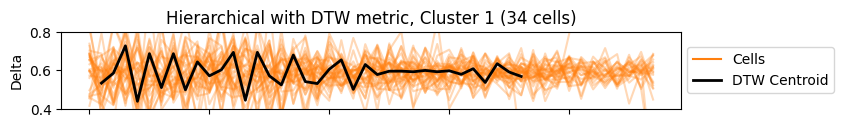

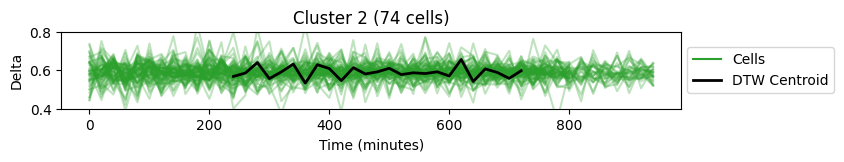

,Cluster 1: 34 cells,Cluster 2: 74 cells
0,Mov. 1 - Cell 9,Mov. 1 - Cell 10
1,Mov. 1 - N,Mov. 1 - Cell 10.1
2,Mov. 1 - O,Mov. 1 - Cell 11
3,Mov. 2 - Cell 1,Mov. 1 - Cell 11.1
4,Mov. 2 - Cell 11,Mov. 1 - Cell 12


In [13]:
# invert: index -> name
identifier_map_fixed = {v: k for k, v in delta_identifier_map.items()}

# Plot clusters with DTW centroids and get cluster identifiers
custom_labels = {1: "Cluster 1", 2: "Cluster 2"}
Hierarch_2cluster_df = plot_cluster_centroids_dtw(
    delta_series,
    cluster_labels=hierarchical_2_labels,
    Z=Z_delta,  # Specify Z here for hierarchical clustering
    color_threshold=10,
    identifier_map=identifier_map_fixed,
    time_index=np.arange(delta_series.shape[1]) * 20,
    model_name="Hierarchical",
    custom_labels=custom_labels
)

# Display the DataFrame with cell identifiers
display(Hierarch_2cluster_df.head())


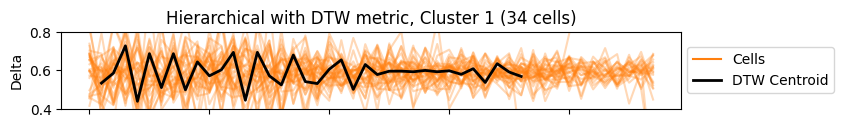

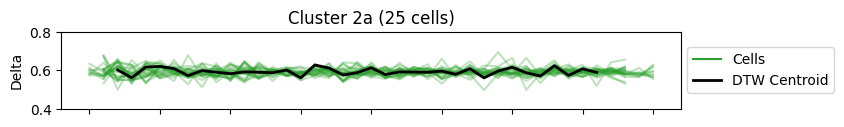

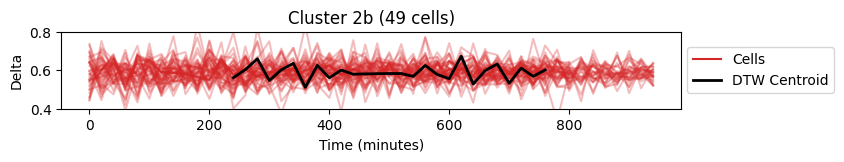

In [14]:
# invert: index -> name
identifier_map_fixed = {v: k for k, v in delta_identifier_map.items()}

# Pass custom labels for report 
custom_labels = {1: "Cluster 1", 2: "Cluster 2a", 3: "Cluster 2b"}
Hierarch_3cluster_df = plot_cluster_centroids_dtw(
    delta_series,
    cluster_labels=hierarchical_3_labels,
    Z=Z_delta,  
    color_threshold=4.5,
    identifier_map=identifier_map_fixed,
    time_index=np.arange(delta_series.shape[1]) * 20,
    model_name="Hierarchical",
    custom_labels=custom_labels
)


### Summary: Hierarchical Clustering with DTW Dissimilarity Profiles

The pairwise-overlap DTW matrix preserves developmental-time positions by comparing each pair only over its shared valid interval. SciPy treats each matrix row as an observation vector (a DTW dissimilarity profile), so `linkage(distance_matrix, method="ward")` applies Ward linkage to Euclidean distances between profiles rather than directly to the pairwise DTW metric.

#### Analytical Assignments
The primary production resolution contains Ward (`K2_DW`) and ordinary scikit-learn KMeans (`K2_DK`) k=2 assignments computed from the same unscaled raw profile rows. The secondary resolution contains the preserved Ward hierarchy (`K3_DW`) with labels `1`, `2a`, and `2b`, plus ordinary KMeans (`K3_DK`) with native local labels. Ward cuts are defined explicitly by cluster count using `criterion="maxclust"`; the dendrogram color threshold is separate from analytical membership.

#### Cluster DataFrames:
- The DataFrames `Hierarch_2cluster_df` with 2 clusters, and `Hierarch_3cluster_df` with three, contain the cell identifiers for each cluster.
- Columns are labeled with the cluster number and the number of cells in each cluster.
- Rows contain the unique identifiers (Movie and Cell).

#### Notes on the DTW Centroid:
- Barycenters are calculated over the common valid interval within each cluster.
- The DTW barycenter is plotted within that common interval, while the entire series is shown in the background for context.


### 5. GMM excluded after revalidation

GMM was part of the original exploratory analysis. Revalidation of the production DTW dissimilarity profiles showed sensitivity to initialization and covariance specification, and the full-covariance model is highly parameterized relative to the dataset size. Simpler covariance models with reproducible multi-start fitting did not support fixing the model at three components. GMM is therefore excluded from production rather than forcing a three-component solution; its diagnostic investigation remains separate.


GMM does not contribute a production assignment or consensus pipeline in this notebook. The DTW production assignments are DW and DK at both the primary k=2 and secondary k=3 resolutions.

### 6. DBSCAN Legacy/Sensitivity Material (Disabled)

DBSCAN is not a production method. Its legacy evaluation remains disabled, accepts the already-computed DTW matrix if deliberately invoked, and creates no assignment output.


In [15]:
# Function to perform DBSCAN classification with DTW
def dbscan_dtw_classification(distance_matrix, eps, min_samples):
    # Fit DBSCAN using the precomputed DTW distance matrix
    db = DBSCAN(eps=eps, min_samples=min_samples, metric="precomputed")
    db.fit(distance_matrix)
    
    # Predict cluster labels
    cluster_labels = db.labels_
    
    return cluster_labels

# Function to evaluate DBSCAN for different eps values
def evaluate_dbscan(distance_matrix, eps_values, min_samples):
    for eps in eps_values:
        print(f"Evaluating DBSCAN with eps={eps}")
        start_time = time.time()
        cluster_labels = dbscan_dtw_classification(distance_matrix, eps, min_samples)
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Time taken: {elapsed_time:.4f} seconds")
        
        # Count the number of clusters and size of each
        unique_clusters, counts = np.unique(cluster_labels, return_counts=True)
        cluster_info = {cluster: count for cluster, count in zip(unique_clusters, counts)}
        
        print(f"Number of clusters found: {len(unique_clusters) - (1 if -1 in unique_clusters else 0)}")
        for cluster, size in cluster_info.items():
            if cluster != -1:
                print(f"Cluster {cluster + 1}: {size} cells")
            else:
                print(f"Noise: {size} cells")
        print("\n")  # Separate outputs for different eps values


In [16]:
# # Evaluate DBSCAN with a range of epsilon values
# # Uncomment below to run DBSCAN
# eps_values = np.arange(0.1, 1.1, 0.1)
# min_samples = 10  # Set min_samples
# evaluate_dbscan(dtw_distance_matrix, eps_values, min_samples)

#### DBSCAN Results Status

DBSCAN is outside the production method set and supplies no assignment, statistic, or figure to downstream notebooks.


### 7. Downstream agreement analysis

Notebook 07 reads the explicit current k = 2 and k = 3 DW/DK assignment files and combines them with the PCA and NMF production assignments.

GMM and its historical hierarchical-overlap matrix remain outside the production execution path.

No GMM or DBSCAN assignment is exported or consumed by the production consensus.

**Current parameters:**

- `nan_threshold = 0.25`
- `truncate_series = False`

These settings preserve the full padded developmental-time coordinate while filtering trajectories with excessive endpoint missingness.

#### Downstream Agreement Analysis

Notebook 07 consumes the explicit k = 2 and k = 3 assignment files produced here. It has no runtime dependency on the historical hierarchical-GMM workflow or any legacy DTW assignment file.


### Exporting Resolution-Specific Production DTW Assignments

The primary k=2 assignments are exported to `data/processed/k2_cluster_assignments_dtw.csv` with columns:

- `Cell_Name`
- `K2_DW`
- `K2_DK`

The secondary k = 3 assignments are exported to `data/processed/k3_cluster_assignments_dtw.csv` with columns `Cell_Name`, `K3_DW`, and `K3_DK`. Ward retains labels `1`, `2a`, and `2b`; KMeans retains native local labels `0`, `1`, and `2` without agreement-based relabeling. The legacy `data/processed/3_cluster_assignments_dtw.csv` is not regenerated and is not a production dependency. GMM and DBSCAN do not contribute production assignments.


In [17]:
# Export freshly computed primary k=2 assignments in deterministic retained-cell order.
k2_dtw_clusters_df = pd.DataFrame({
    "Cell_Name": retained_cell_names,
    "K2_DW": K2_DW,
    "K2_DK": K2_DK,
})
assert k2_dtw_clusters_df.shape == (108, 3)
assert k2_dtw_clusters_df.columns.tolist() == ["Cell_Name", "K2_DW", "K2_DK"]
assert k2_dtw_clusters_df["Cell_Name"].tolist() == retained_cell_names
assert k2_dtw_clusters_df["Cell_Name"].is_unique
assert not k2_dtw_clusters_df.isna().any().any()
assert pd.api.types.is_integer_dtype(k2_dtw_clusters_df["K2_DW"])
assert pd.api.types.is_integer_dtype(k2_dtw_clusters_df["K2_DK"])
assert set(k2_dtw_clusters_df["K2_DW"]) == {1, 2}
assert set(k2_dtw_clusters_df["K2_DK"]) == {1, 2}
assert k2_dtw_clusters_df["K2_DW"].value_counts().sort_index().to_dict() == {1: 34, 2: 74}
assert k2_dtw_clusters_df["K2_DK"].value_counts().sort_index().to_dict() == {1: 40, 2: 68}

# Export secondary k=3 Ward and KMeans assignments in the same cell order.
k3_dtw_clusters_df = pd.DataFrame({
    "Cell_Name": retained_cell_names,
    "K3_DW": K3_DW,
    "K3_DK": K3_DK,
})
assert k3_dtw_clusters_df.shape == (108, 3)
assert k3_dtw_clusters_df.columns.tolist() == ["Cell_Name", "K3_DW", "K3_DK"]
assert k3_dtw_clusters_df["Cell_Name"].tolist() == retained_cell_names
assert k3_dtw_clusters_df["Cell_Name"].is_unique
assert not k3_dtw_clusters_df.isna().any().any()
assert set(k3_dtw_clusters_df["K3_DW"]) == {"1", "2a", "2b"}
assert k3_dtw_clusters_df["K3_DW"].value_counts().to_dict() == {"2b": 49, "1": 34, "2a": 25}
assert set(k3_dtw_clusters_df["K3_DK"]) == {0, 1, 2}
assert sorted(k3_dtw_clusters_df["K3_DK"].value_counts().tolist()) == [28, 31, 49]

k2_output_path = PROCESSED_DATA_DIR / "k2_cluster_assignments_dtw.csv"
k3_output_path = PROCESSED_DATA_DIR / "k3_cluster_assignments_dtw.csv"
k2_dtw_clusters_df.to_csv(k2_output_path, index=False)
k3_dtw_clusters_df.to_csv(k3_output_path, index=False)
print(f"Wrote {k2_output_path} with columns {k2_dtw_clusters_df.columns.tolist()}")
print(f"Wrote {k3_output_path} with columns {k3_dtw_clusters_df.columns.tolist()}")
print("Legacy data/processed/3_cluster_assignments_dtw.csv was not regenerated.")
display(k2_dtw_clusters_df.head())
display(k3_dtw_clusters_df.head())


Wrote c:\Users\trogalsky\OneDrive - Canadian Mennonite University\_Research Projects\Drosophila_ML\2026-Book Chapter Code\data\processed\k2_cluster_assignments_dtw.csv with columns ['Cell_Name', 'K2_DW', 'K2_DK']
Wrote c:\Users\trogalsky\OneDrive - Canadian Mennonite University\_Research Projects\Drosophila_ML\2026-Book Chapter Code\data\processed\k3_cluster_assignments_dtw.csv with columns ['Cell_Name', 'K3_DW', 'K3_DK']
Legacy data/processed/3_cluster_assignments_dtw.csv was not regenerated.


,Cell_Name,K2_DW,K2_DK
0,Mov. 1 - Cell 10,2,2
1,Mov. 1 - Cell 10.1,2,2
2,Mov. 1 - Cell 11,2,2
3,Mov. 1 - Cell 11.1,2,2
4,Mov. 1 - Cell 12,2,2


,Cell_Name,K3_DW,K3_DK
0,Mov. 1 - Cell 10,2a,0
1,Mov. 1 - Cell 10.1,2a,0
2,Mov. 1 - Cell 11,2a,0
3,Mov. 1 - Cell 11.1,2b,0
4,Mov. 1 - Cell 12,2a,0


### Book Chapter Figure 2

This cell assembles the production DTW hierarchy and three-cluster trajectory/barycenter summaries into the publication composite. It consumes the already-computed linkage and assignments and adds no new analysis; the dendrogram threshold is a visualization aid rather than the analytical cluster definition.

{'pixels': (2764, 2741), 'png_dpi': (599.9988, 599.9988), 'tiff_dpi': (600.0, 600.0), 'tiff_compression': 'tiff_lzw'}


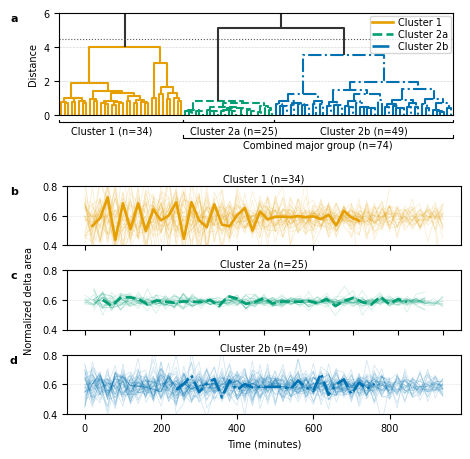

In [18]:
# Assemble the Section 5 publication composite from finalized analysis objects.
from PIL import Image

time_index = np.arange(delta_series.shape[1]) * 20
cluster_names = {1: "Cluster 1", 2: "Cluster 2a", 3: "Cluster 2b"}
cluster_colors = {1: "#E69F00", 2: "#009E73", 3: "#0072B2"}
cluster_linestyles = {1: "-", 2: "--", 3: "-."}
expected_three_cluster_sizes = {1: 34, 2: 25, 3: 49}
observed_three_cluster_sizes = {
    cluster_id: int(np.sum(hierarchical_3_labels == cluster_id))
    for cluster_id in np.unique(hierarchical_3_labels)
}
assert observed_three_cluster_sizes == expected_three_cluster_sizes
assert sorted(np.unique(hierarchical_2_labels, return_counts=True)[1].tolist()) == [34, 74]

FIG_DPI = 600
FIG_FONT_PT = 7
FIG_PANEL_PT = 8
FIG2_WIDTH_PX = 2764
FIG2_HEIGHT_PX = 2741
fig = plt.figure(
    figsize=(
        FIG2_WIDTH_PX / FIG_DPI,
        np.nextafter(FIG2_HEIGHT_PX / FIG_DPI, np.inf),
    ),
    facecolor="white",
)
# Panel rows are 75% of their prior heights; the a-b spacer is slightly larger,
# while the b-c and c-d spacer heights are preserved.
grid = fig.add_gridspec(
    7, 1, height_ratios=[0.9675, 0.6825, 0.5625, 0.24, 0.5625, 0.24, 0.5625], hspace=0.0
)
axes = np.asarray([
    fig.add_subplot(grid[0]),
    fig.add_subplot(grid[2]),
    fig.add_subplot(grid[4]),
    fig.add_subplot(grid[6]),
])
# Preserve the finalized top/bottom margins in physical units after reducing height.
fig_height_in = FIG2_HEIGHT_PX / FIG_DPI
fig.subplots_adjust(
    left=0.110, right=0.965,
    top=1 - (0.09375 / fig_height_in),
    bottom=0.46875 / fig_height_in,
)
trajectory_x_shift = 0.017
for trajectory_axis in axes[1:]:
    trajectory_position = trajectory_axis.get_position()
    trajectory_axis.set_position([
        trajectory_position.x0 + trajectory_x_shift, trajectory_position.y0,
        trajectory_position.width, trajectory_position.height,
    ])

# (a) Existing Ward hierarchy; 4.5 controls branch colors only.
ax = axes[0]
# Determine each linkage node's analytical descendants, then style terminal branches redundantly.
n_leaves = len(hierarchical_3_labels)
descendant_clusters = {
    leaf_id: {int(hierarchical_3_labels[leaf_id])}
    for leaf_id in range(n_leaves)
}
for row_index, linkage_row in enumerate(Z_delta):
    left_child, right_child = int(linkage_row[0]), int(linkage_row[1])
    descendant_clusters[n_leaves + row_index] = (
        descendant_clusters[left_child] | descendant_clusters[right_child]
    )

def analytical_branch_color(node_id):
    node_clusters = descendant_clusters[int(node_id)]
    if len(node_clusters) == 1:
        return cluster_colors[next(iter(node_clusters))]
    return "#333333"

dendro = dendrogram(
    Z_delta,
    no_labels=True,
    color_threshold=4.5,
    link_color_func=analytical_branch_color,
    ax=ax,
)
color_to_linestyle = {
    cluster_colors[cluster_id]: cluster_linestyles[cluster_id]
    for cluster_id in (1, 2, 3)
}
collection_colors = list(dict.fromkeys(dendro["color_list"]))
assert len(ax.collections) == len(collection_colors)
for collection, branch_color in zip(ax.collections, collection_colors):
    collection.set_linestyle(color_to_linestyle.get(branch_color, "solid"))
    collection.set_clip_on(True)
ax.axhline(4.5, color="0.35", linestyle=":", linewidth=0.8)
ax.set_ylim(0, 6)
ax.set_yticks([0, 2, 4, 6])
ax.set_ylabel("Distance", fontsize=FIG_FONT_PT)
# ax.set_xlabel("Cells", fontsize=FIG_FONT_PT, labelpad=59)
ax.tick_params(axis="both", labelsize=FIG_FONT_PT)
ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.55)

# Dendrogram leaf centers are 5, 15, 25, ...; derive every span from leaf order.
leaf_order = np.asarray(dendro["leaves"])
leaf_centers = 5 + 10 * np.arange(len(leaf_order))
ordered_three_labels = np.asarray(hierarchical_3_labels)[leaf_order]
ordered_two_labels = np.asarray(hierarchical_2_labels)[leaf_order]
xaxis_transform = ax.get_xaxis_transform()

def add_leaf_span_bracket(axis, x0, x1, y, label, text_y, text_x_offset=0):
    axis.plot(
        [x0, x0, x1, x1], [y + 0.025, y, y, y + 0.025],
        transform=xaxis_transform, color="black", linewidth=0.8, clip_on=False,
    )
    axis.text(
        (x0 + x1) / 2 + text_x_offset, text_y, label, transform=xaxis_transform,
        ha="center", va="top", fontsize=FIG_FONT_PT, clip_on=False,
    )

cluster_label_x_offset = {1: -25, 2: 15, 3: 0}
for cluster_id in (1, 2, 3):
    positions = np.flatnonzero(ordered_three_labels == cluster_id)
    assert np.array_equal(positions, np.arange(positions[0], positions[-1] + 1))
    add_leaf_span_bracket(
        ax, leaf_centers[positions[0]] - 5, leaf_centers[positions[-1]] + 5,
        -0.075, f"{cluster_names[cluster_id]} (n={len(positions)})", -0.105,
        cluster_label_x_offset[cluster_id],
    )

two_group_ids, two_group_counts = np.unique(ordered_two_labels, return_counts=True)
large_group_id = two_group_ids[np.argmax(two_group_counts)]
large_group_positions = np.flatnonzero(ordered_two_labels == large_group_id)
assert len(large_group_positions) == 74
assert np.array_equal(
    large_group_positions,
    np.arange(large_group_positions[0], large_group_positions[-1] + 1),
)
add_leaf_span_bracket(
    ax, leaf_centers[large_group_positions[0]] - 5, leaf_centers[large_group_positions[-1]] + 5,
    -0.225, "Combined major group (n=74)", -0.255,
)

# (b)-(d) Complete observed trajectories with barycenters on common valid intervals.
for panel_index, cluster_id in enumerate((1, 2, 3), start=1):
    ax = axes[panel_index]
    cluster_indices = np.where(hierarchical_3_labels == cluster_id)[0]
    cluster_series = delta_series[cluster_indices]

    valid_start = 0
    valid_end = delta_series.shape[1] - 1
    for series in cluster_series:
        valid_indices = np.where(~np.isnan(series))[0]
        valid_start = max(valid_start, valid_indices[0])
        valid_end = min(valid_end, valid_indices[-1])

    truncated_series = [series[valid_start:valid_end + 1] for series in cluster_series]
    valid_series = [series for series in truncated_series if not np.isnan(series).all()]
    common_time = time_index[valid_start:valid_end + 1]
    barycenter = np.asarray(dtw_barycenter_averaging(valid_series)).squeeze()

    for series in cluster_series:
        ax.plot(
            time_index, series, color=cluster_colors[cluster_id],
            alpha=0.18, linewidth=0.55, linestyle="-",
        )
    ax.plot(
        common_time, barycenter, color=cluster_colors[cluster_id],
        linewidth=1.9, linestyle=cluster_linestyles[cluster_id],
    )
    ax.set_ylim(0.4, 0.8)
    ax.set_yticks([0.4, 0.6, 0.8])
    ax.set_title(
        f"{cluster_names[cluster_id]} (n={len(cluster_series)})",
        fontsize=FIG_FONT_PT, pad=3,
    )
    ax.tick_params(axis="both", labelsize=FIG_FONT_PT)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4)
    if panel_index < 3:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Time (minutes)", fontsize=FIG_FONT_PT)

trajectory_block_center = (axes[1].get_position().y1 + axes[3].get_position().y0) / 2
fig.text(
    0.045, trajectory_block_center, "Normalized delta area",
    rotation=90, ha="center", va="center", fontsize=FIG_FONT_PT,
)

cluster_handles = [
    mlines.Line2D(
        [], [], color=cluster_colors[cluster_id],
        linestyle=cluster_linestyles[cluster_id], linewidth=1.9,
        label=cluster_names[cluster_id],
    )
    for cluster_id in (1, 2, 3)
]
axes[0].legend(
    handles=cluster_handles, loc="upper right",
    fontsize=FIG_FONT_PT, frameon=True, borderpad=0.2, handlelength=2.2,
    handletextpad=0.5, labelspacing=0.2, borderaxespad=0.25,
)

for axis, panel_letter in zip(axes, "abcd"):
    fig.text(
        0.012, axis.get_position().y1, panel_letter, transform=fig.transFigure,
        fontsize=FIG_PANEL_PT, fontweight="bold", ha="center", va="top",
    )

png_path = FIGURES_DIR / "Book_Chapter_Fig_2.png"
tiff_path = FIGURES_DIR / "Book_Chapter_Fig_2.tiff"
fig.savefig(png_path, dpi=FIG_DPI, facecolor="white")
fig.savefig(
    tiff_path, dpi=FIG_DPI, facecolor="white",
    pil_kwargs={"compression": "tiff_lzw"},
)
with Image.open(png_path) as png_image:
    png_size, png_dpi = png_image.size, png_image.info.get("dpi")
with Image.open(tiff_path) as tiff_image:
    tiff_size = tiff_image.size
    tiff_dpi = tiff_image.info.get("dpi")
    tiff_compression = tiff_image.info.get("compression")
assert png_size == tiff_size == (FIG2_WIDTH_PX, FIG2_HEIGHT_PX)
assert png_dpi and all(abs(value - FIG_DPI) < 0.1 for value in png_dpi)
assert tiff_dpi and all(abs(value - FIG_DPI) < 0.1 for value in tiff_dpi)
assert str(tiff_compression).lower() in {"tiff_lzw", "lzw"}
print({"pixels": png_size, "png_dpi": png_dpi, "tiff_dpi": tiff_dpi, "tiff_compression": tiff_compression})
plt.show()